# Preparations

In [1]:
import os
import sys
import glob
import json
import cv2
import numpy as np
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [ ]:
%env OPENAI_API_KEY=<your_openai_apikey>

In [ ]:
from PIL import Image
from IPython.core.display import HTML
from engine.utils import ProgramGenerator, ProgramInterpreter
geoprog3d_dataset_dict = {
    "task_grounding":   "log_grounding",        # GRD
    "task_counting":    "log_counting",         # CNT
    "task_distance":    "log_estimation",       # MES-D
    "task_height":      "log_estimation_height",# MES-H
    "task_r+counting":  "log_reasoning",        # SPR
    "task_r+distance":  "log_reasoning",        # SPR
    "task_r+grounding": "log_reasoning",        # SPR
    "task_r+height":    "log_reasoning"         # CMP
}

In [4]:
dataset_name = "google_earth"
scene_name = "US-NewYork-Queens-10-Center-Blvd-R375-A410"
task_name = "task_grounding"
# task_name = "task_counting"
# task_name = "task_distance"
# task_name = "task_height"
# task_name = "task_r+grounding"
# task_name = "task_r+counting"
# task_name = "task_r+distance"
# task_name = "task_r+height"
geoprog3d_dataset_name = geoprog3d_dataset_dict[task_name]

project_root = "/workspace/t2024/"
annotations_parent_dir = f"{project_root}geoprog3d/datasets/{dataset_name}/{scene_name}/{task_name}/"
ins_fname_json = f"{project_root}geoprog3d/ins_fname.json"
output_path = f"{project_root}LoG/renders4visprog/{scene_name}/similarity"
heatmap_coords_json_path = os.path.join(output_path, 'heatmap_coords.json')
similarity_count_json = f"{project_root}geoprog3d/similarity_count.json"

if task_name in ["task_r+grounding"]:
    from functools import partial
    from prompts.SPR_GRD import create_prompt
    prompter = partial(create_prompt,method='all')
    generator = ProgramGenerator(prompter=prompter)
elif task_name in ["task_r+counting"]:
    from functools import partial
    from prompts.SPR_CNT import create_prompt
    prompter = partial(create_prompt,method='all')
    generator = ProgramGenerator(prompter=prompter)
elif task_name in ["task_r+distance"]:
    from functools import partial
    from prompts.SPR_DIST import create_prompt
    prompter = partial(create_prompt,method='all')
    generator = ProgramGenerator(prompter=prompter)
elif task_name in ["task_r+height"]:
    from functools import partial
    from prompts.CMP import create_prompt
    prompter = partial(create_prompt,method='all')
    generator = ProgramGenerator(prompter=prompter)
else:
    def create_prompt(instruction):
        return PROMPT.format(instruction=instruction)

    if task_name == "task_grounding":
        from prompts.GRD import PROMPT

    elif task_name == "task_counting":
        from prompts.CNT import PROMPT

    elif task_name == "task_distance":
        from prompts.MES_D import PROMPT

    elif task_name == "task_height":
        from prompts.MES_H import PROMPT
    generator = ProgramGenerator(prompter=create_prompt)

In [ ]:
interpreter = ProgramInterpreter(dataset=geoprog3d_dataset_name)

# Load queries

In [ ]:
def get_mask_coordinates(H, W, P):
    # polygon to mask
    mask = np.zeros((H, W), dtype=np.uint8)
    pts = np.array(P, dtype=np.int32)
    cv2.fillPoly(mask, [pts], 255)
    y_coords, x_coords = np.where(mask == 255)
    M = list(zip(x_coords, y_coords))
    return M, mask

def get_bbox_mask_coordinates(H, W, P):
    # rectangle to mask
    x1, y1 = P[0]
    x2, y2 = P[1]
    x_min, x_max = min(x1, x2), max(x1, x2)
    y_min, y_max = min(y1, y2), max(y1, y2)
    
    x_coords = np.arange(x_min, x_max + 1)
    y_coords = np.arange(y_min, y_max + 1)
    
    xx, yy = np.meshgrid(x_coords, y_coords)
    xx = xx.astype(int)
    yy = yy.astype(int)
    
    M = list(zip(xx.ravel(), yy.ravel()))
    
    return M

# if task_name == "task_grounding":
annotations_parent_dir = f"{project_root}geoprog3d/datasets/{dataset_name}/{scene_name}/task_grounding/"
annotated_json_list = list(glob.glob(annotations_parent_dir + "*.json"))
query_info_all = []
for ins_json in annotated_json_list:
    with open(ins_json, 'r') as f:
        loaded_data = json.load(f)

    img_base_name_wo_ext = os.path.basename(ins_json).split(".")[0]
    # get unique_label
    loaded_data_label_list = []
    for one_ano_data in loaded_data["shapes"]:
        if one_ano_data["shape_type"] == "polygon":
            loaded_data_label_list.append(one_ano_data["label"])
    unique_loaded_data_label_list = list(np.unique(loaded_data_label_list))

    # get query info by unique label
    query_info_by_one_json = []
    for ul in unique_loaded_data_label_list:
        mask_point_list = []
        rectangle_point_list = []

        for one_ano_data in loaded_data["shapes"]:
            if one_ano_data["label"] == ul:
                if one_ano_data["shape_type"] == "polygon":
                    H = loaded_data["imageHeight"]
                    W = loaded_data["imageWidth"]
                    P = one_ano_data["points"]
                    mask_coordinates, mask = get_mask_coordinates(H, W, P)
                    mask_point_list.extend(list(mask_coordinates))

                if one_ano_data["shape_type"] == "rectangle":
                    H = loaded_data["imageHeight"]
                    W = loaded_data["imageWidth"]
                    P = one_ano_data["points"]
                    mask_coordinates = get_bbox_mask_coordinates(H, W, P)
                    rectangle_point_list.extend(mask_coordinates)

        one_imagePath = loaded_data["imagePath"]
        one_imagePath = one_imagePath.replace('\\', '/')
        # if "images" in one_imagePath:
        #     one_imagePath = one_imagePath.split("images")[-1][1:]
        one_imagePath = os.path.basename(one_imagePath)
            
        one_imageHeight = loaded_data["imageHeight"]
        one_imageWidth = loaded_data["imageWidth"]
        query_info = {
            "label":ul,
            "mask":mask_point_list,
            "rectangle":rectangle_point_list,
            "path":one_imagePath,
            "height":one_imageHeight,
            "width":one_imageWidth
        }
        query_info_by_one_json.append(query_info)
    query_info_all.extend(query_info_by_one_json)

for d_n, d in enumerate(query_info_all):
    if d_n == 0:
        print(d["label"])   # The playing field to the east of <The View>
        print(d["path"])    # US-NewYork-Queens-10-Center-Blvd-R375-A410_44.jpeg  1/DJI_0817.JPG
        print(d["rectangle"][:5])   # [(528, 434), (529, 434), (530, 434), (531, 434), (532, 434)]
        print(d["mask"][:5])    # [(539, 433), (540, 433), (541, 433), (542, 433), (543, 433)]
        print(d["height"])    # 538
        print(d["width"])   # 959

if task_name == "task_grounding":
    pass

else:
    annotations_parent_dir = f"{project_root}geoprog3d/datasets/{dataset_name}/{scene_name}/{task_name}/"
    height = d["height"]
    width = d["width"]
    task_anno_json = list(glob.glob(annotations_parent_dir + "*.json"))[0]
    with open(task_anno_json, 'r') as f:
        loaded_dist_query_dict = json.load(f)
    query_info_all = []
    for k, v_list in loaded_dist_query_dict.items():
        fname = k
        for v in v_list:
            v["label"]
            v["gt"]

            query_info = {
                "label":v["label"],
                "gt":v["gt"],
                "path":fname,
                "height":height,
                "width":width
            }
            query_info_all.append(query_info)

## GRD

In [ ]:
def calculate_iou(L1, L2, H, W):
    mask1 = np.zeros((H, W), dtype=np.uint8)
    mask2 = np.zeros((W, H), dtype=np.uint8)
    mask1[L1[:, 1], L1[:, 0]] = 255
    mask2[L2[:, 1], L2[:, 0]] = 255
    mask2 = np.rot90(mask2,3)

    intersection = cv2.bitwise_and(mask1, mask2)
    union = cv2.bitwise_or(mask1, mask2)
    intersection_area = np.sum(intersection)
    union_area = np.sum(union)    
    iou = intersection_area / union_area if union_area > 0 else 0
    iou = iou if iou < 1 else 0

    return iou,mask1,mask2

count = 0    
hit = 0
iou_threshold = 0.25
iou_list = []
for d_n, d in enumerate(query_info_all):
    ### You need to record these in order to refer to them in render_visprog_eval_view.py
    ins_fname_dict = {"fname":d["path"],"height":d["height"],"width":d["width"],"eval_index_list":[0]}
    with open(ins_fname_json, 'w') as f:
        json.dump(ins_fname_dict, f)

    ### Visual Program Generation
    instruction = d["label"]
    prog,_ = generator.generate(instruction)
    # prog="ANSWER0=GetSimilarAreas(query='a red lettering signboard',area_filter_flag=False)\nFINAL_RESULT=RESULT(var=ANSWER0)"
    print(instruction)
    print(prog)
    print("---", prog.count("GetSimilarAreas"))

    # flag
    similarity_c = prog.count("GetSimilarAreas")    
    res_dict = {"requirement_count":similarity_c}
    with open(similarity_count_json, 'w') as f:
        json.dump(res_dict, f)

    ### Visual Program Execution
    try:
        result, prog_state, html_str = interpreter.execute(prog,None,inspect=True)
    except:
        pass
    with open(heatmap_coords_json_path, 'r') as f:
        loaded_data = json.load(f)
    for image_path, coords in list(loaded_data.items()):
        segment_list = coords# Pixel set of a heatmap
        print("activated pixels: ", len(segment_list))
        # print(segment_list[:5])# [[523, 0], [524, 0], [524, 1], [523, 2], [524, 2]]

    ### IoU with GT
    d["mask"]# GT
    if len(segment_list) > 0:
        iou,m1,m2 = calculate_iou(np.array(d["mask"]), np.array(segment_list), d["height"], d["width"])
    else:
        iou = 0
    print(f"IoU: {iou}")
    iou_list.append(iou)
    if iou > iou_threshold:
        hit += 1
    count += 1
    print("==============================")
    break

print(f"{hit}/{count}")

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(m1)
plt.show()
plt.imshow(m2)
plt.show()

In [ ]:
HTML(html_str)

## CNT,MES-H,MES-D

In [ ]:
gt_list = []
pred_list = []
for d_n, d in enumerate(query_info_all):
    ### You need to record these in order to refer to them in render_visprog_eval_view.py
    ins_fname_dict = {"fname":d["path"],"height":d["height"],"width":d["width"],"eval_index_list":[0]}
    with open(ins_fname_json, 'w') as f:
        json.dump(ins_fname_dict, f)

    ### Visual Program Generation
    instruction = d["label"]
    prog,_ = generator.generate(instruction)
    # prog = "ANSWER0=ObjCounting(query='parking lot',area_filter_flag=False)\nFINAL_RESULT=RESULT(var=ANSWER0)"
    print(instruction)
    print(prog)
    print("---")

    ### Visual Program Execution
    try:
        result, prog_state, html_str = interpreter.execute(prog,None,inspect=True)
        print("gt:{}, pred:{}".format(d["gt"],result))
        pred_list.append(result)
    except:
        pred_list.append(-1)

    gt_list.append(d["gt"])
    print("==============================")

In [ ]:
HTML(html_str)

## SPR & CMP

In [ ]:
gt_list = []
pred_list = []
for d_n, d in enumerate(query_info_all):
    ### You need to record these in order to refer to them in render_visprog_eval_view.py
    ins_fname_dict = {"fname":d["path"],"height":d["height"],"width":d["width"],"eval_index_list":[0]}
    with open(ins_fname_json, 'w') as f:
        json.dump(ins_fname_dict, f)

    ### Visual Program Generation
    question = d["label"]
    # question = "Which is higher, the skyscraper that is closest to <45-45 Center Blvd> or <The View>?"
    prog,_ = generator.generate(dict(question=question))
    print(question)
    print(prog)
    print("---")

    ### Visual Program Execution
    try:
        result, prog_state, html_str = interpreter.execute(prog,None,inspect=True)
        print("gt:{}, pred:{}".format(d["gt"],result))
        pred_list.append(result)
    except:
        ex_pred = "error"
        if d["gt"] == "yes":
            ex_pred = "no"
        elif d["gt"] == "no":
            ex_pred = "yes"            
        print("gt:{}, pred:{}".format(d["gt"],ex_pred))
        pred_list.append(ex_pred)
    gt_list.append(d["gt"])
    print("==============================")



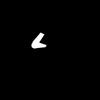
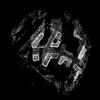
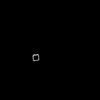
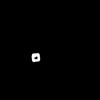
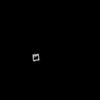
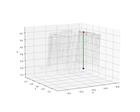
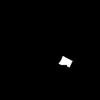
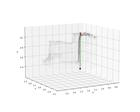

In [14]:
out_html=HTML(html_str)
html = out_html.data
with open('out_html.html', 'w') as f:
    f.write(html)
out_html